# Bayesian M2M Gaussian experiment

This notebook is only the experiment driver and plotting layer.

The computational stages are separate scripts:

1. Generate and freeze \(D=\{(X^i,Y^i)\}_{i=1}^n\) and a separate unseen \((X^0,Y^0)\).
2. Call `collect_pca_trajectory_fixed.py` to pretrain and construct the PCA subspace from this fixed \(D\).
3. Call `run_ess.py` to sample the posterior PCA coordinates \(\phi\).
4. Call `posterior_predictive.py` to evaluate the posterior predictive at \(X^0\).

The notebook produces:
- a pair plot of the \(K\) posterior coordinates \(\phi\);
- the posterior predictive distribution of the target mean \(m_\phi(X^0)\).


In [ ]:
!git clone https://github.com/djskog/simple_gaussian_example.git/
%cd /content/simple_gaussian_example

fatal: destination path 'simple_gaussian_example' already exists and is not an empty directory.


In [25]:
!git -C /content/simple_gaussian_example pull

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 10 (delta 5), reused 8 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (10/10), 1.08 MiB | 11.21 MiB/s, done.
From https://github.com/djskog/simple_gaussian_example
   d48df32..8df9d96  main       -> origin/main
Updating d48df32..8df9d96
Fast-forward
 notebooks/colab_bayesian_m2m_driver.ipynb | 1395 +++++++++++++++++++++++++++++
 run_ess.py                                |    3 +
 2 files changed, 1398 insertions(+)
 create mode 100644 notebooks/colab_bayesian_m2m_driver.ipynb


In [ ]:
from pathlib import Path
import sys
import subprocess
import random

import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Project setup
# ------------------------------------------------------------

# In Colab, make sure the notebook is running from the repository root.
PROJECT_ROOT = Path.cwd()

print("Working directory:", PROJECT_ROOT)

# Check that the project files are actually here.
required_files = [
    "datasets.py",
    "utils.py",
    "collect_pca_trajectory.py",
    "run_ess.py",
    "posterior_predictive.py",
]

missing = [f for f in required_files if not (PROJECT_ROOT / f).exists()]

if missing:
    raise FileNotFoundError(
        "Missing project files:\n" + "\n".join(f"  - {f}" for f in missing)
    )

# Make local project modules importable.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from datasets import generate_location_data
from utils import bayes_optimal_target_mean, get_df_label

# Output directories
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
FIGURE_DIR = PROJECT_ROOT / "figures"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Working directory: /content/simple_gaussian_example
Project root: /content/simple_gaussian_example
Python: /usr/bin/python3
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [ ]:
# Experiment configuration

SEED = 7

N_TRAIN_MEASURES = 500
N_TEST_MEASURES = 10
N_POINTS = 128

beta = torch.zeros(2)
Sigma_Z = torch.eye(2)
Sigma_X = 0.25 * torch.eye(2)
Sigma_Y = 0.10 * torch.eye(2)
B0 = torch.eye(2)

T_DFs = [5.0, np.inf]  

# PCA trajectory
PRETRAIN_EPOCHS = 50
PRETRAIN_LR = 1e-3
TRAJECTORY_EPOCHS = 50
TRAJECTORY_LR = 1e-2
MAX_SNAPSHOTS = 20
PCA_RANK = 5
BATCH_SIZE = 32

# ESS
PRIOR_STD = 1
ESS_BURN_IN = 100
ESS_NUM_SAMPLES = 1000
ESS_THIN = 1
ESS_TEMPERATURE = 1e3
ESS_SEED = 1234

FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

## 1. Generate and freeze \(D\) and an unseen test pair

We materialize the observations once. The later PCA and ESS scripts use these exact tensors, so the likelihood is deterministic conditional on the fixed dataset.


In [ ]:
#generate and save D
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

for df in T_DFs:
    data = generate_location_data(
        num_measures=N_TRAIN_MEASURES,
        num_points=N_POINTS,
        df=df,
        beta=beta,
        Sigma_Z=Sigma_Z,
        Sigma_X=Sigma_X,
        Sigma_Y=Sigma_Y,
        B0=B0,
        seed=SEED,
    )
    
    path = (CHECKPOINT_DIR / f"{get_df_label(df)}_fixed_D.pt")
    torch.save(data, path)
    print("Saved:", path)




D source: (500, 128, 2)
D target: (500, 128, 2)
Saved: /content/simple_gaussian_example/checkpoints/gaussian_fixed_D.pt
D source: (500, 128, 2)
D target: (500, 128, 2)
Saved: /content/simple_gaussian_example/checkpoints/student_t_fixed_D.pt


In [ ]:
#generate and save X0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

test_data = generate_location_data(
        num_measures=N_TEST_MEASURES,
        num_points=N_POINTS,
        df=np.inf,  # Gaussian case
        beta=beta,
        Sigma_Z=Sigma_Z,
        Sigma_X=Sigma_X,
        Sigma_Y=Sigma_Y,
        B0=B0,
        seed=SEED,
    )

path = (CHECKPOINT_DIR / f"{get_df_label(np.inf)}_fixed_test_data.pt")
torch.save(test_data, path)
print("Saved:", path)

D source: (10, 128, 2)
D target: (10, 128, 2)
Saved: /content/simple_gaussian_example/checkpoints/gaussian_fixed_test_data.pt


## 2. Construct the PCA subspace

The separate collector starts from a fresh transformer, pretrains on the fixed \(D\), continues with constant-step-size SGD, forms the SWA shift \(\hat w\), and computes the scaled PCA basis \(P\), giving

\[
w(\phi)=\hat w+P\phi.
\]


In [ ]:
pca_script = PROJECT_ROOT / "collect_pca_trajectory.py"

if not pca_script.exists():
    raise FileNotFoundError(f"Missing {pca_script}")

for df in T_DFs:
    train_data_path = CHECKPOINT_DIR / f"{get_df_label(df)}_fixed_D.pt"
    pca_path = CHECKPOINT_DIR / f"{get_df_label(df)}_pca_subspace.pt"

    cmd = [
        sys.executable,
        "-u",
        str(pca_script),
        "--fixed-data", str(train_data_path),
        "--output", str(pca_path),
        "--pretrain-epochs", str(PRETRAIN_EPOCHS),
        "--pretrain-lr", str(PRETRAIN_LR),
        "--trajectory-epochs", str(TRAJECTORY_EPOCHS),
        "--trajectory-lr", str(TRAJECTORY_LR),
        "--max-snapshots", str(MAX_SNAPSHOTS),
        "--pca-rank", str(PCA_RANK),
        "--batch-size", str(BATCH_SIZE),
        "--seed", str(SEED),
    ]

    print("Running PCA collector...", flush=True)

    process = subprocess.Popen(
        cmd,
        cwd=PROJECT_ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)

    return_code = process.wait()

    if return_code != 0:
        raise subprocess.CalledProcessError(
            return_code,
            cmd,
        )

    print(f"{get_df_label(df)} PCA collector finished.", flush=True)


Running PCA collector...
PCA subspace from fixed training dataset D
Fixed dataset : /content/simple_gaussian_example/checkpoints/gaussian_fixed_D.pt
Output        : /content/simple_gaussian_example/checkpoints/gaussian_pca_subspace.pt
Device        : cuda
Loading fixed dataset...
source shape: (500, 128, 2)
target shape: (500, 128, 2)
/content/simple_gaussian_example/models/gaussian_transformer.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
Trainable parameters: 414,594

Starting pretraining...
[pretrain] epoch 0001/0050 | NLL = 297.921296
[pretrain] epoch 0002/0050 | NLL = 91.966316
[pretrain] epoch 0003/0050 | NLL = 85.793172
[pretrain] epoch 0004/0050 | NLL = 82.423911
[pretrain] epoch 0005/0050 | NLL = 83.580463
[pretrain] epoch 0006/0050 | NLL = 79.103545
[pretrain] epoch 0007/0050 | NLL = 77.127015
[pretrain] epoch 0008/0050 | NLL = 76.336152
[pretrain] epoch 0

In [20]:
##load PCA checkpoint and print info

pca_checkpoint = torch.load(
    path,
    map_location="cpu",
    weights_only=False,
)

print("PCA basis shape:", tuple(pca_checkpoint["pca_basis"].shape))
print("Explained variance ratio:")
print(pca_checkpoint["explained_variance_ratio"])


KeyError: 'pca_basis'

## 3. Sample \(\phi\mid D\) with elliptical slice sampling

The ESS script targets

\[
p_T(\phi\mid D)
\propto
p(D\mid\phi)^{1/T}p(\phi),
\qquad
\phi\sim N(0,I).
\]

All likelihood evaluations use the frozen dataset \(D\).


In [ ]:
ess_script = PROJECT_ROOT / "run_ess.py"
if not ess_script.exists():
    raise FileNotFoundError(f"Missing {ess_script}")

for df in T_DFs:
    train_data_path = CHECKPOINT_DIR / f"{get_df_label(df)}_fixed_D.pt"
    pca_path = CHECKPOINT_DIR / f"{get_df_label(df)}_pca_subspace.pt"
    posterior_path = CHECKPOINT_DIR / f"{get_df_label(df)}_posterior_samples.pt"

    cmd = [
        sys.executable,
        "-u",
        str(ess_script),
        "--fixed-data", str(train_data_path),
        "--pca", str(pca_path),
        "--output", str(posterior_path),
        "--prior-std", str(PRIOR_STD),
        "--burn-in", str(ESS_BURN_IN),
        "--num-samples", str(ESS_NUM_SAMPLES),
        "--thin", str(ESS_THIN),
        "--temperature", str(ESS_TEMPERATURE),
        "--batch-size", str(BATCH_SIZE),
        "--seed", str(ESS_SEED),
    ]

    print("Running ESS...", flush=True)

    process = subprocess.Popen(
        cmd,
        cwd=PROJECT_ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)

    return_code = process.wait()

    if return_code != 0:
        raise subprocess.CalledProcessError(
            return_code,
            cmd,
        )


Running ESS...
Hi
Starting run_ess.py
Device: cuda
Loading fixed dataset...
Fixed dataset loaded.
Loading PCA checkpoint...
PCA checkpoint loaded.
Source shape: (500, 128, 2)
Target shape: (500, 128, 2)
Constructing subspace model...
/content/simple_gaussian_example/models/gaussian_transformer.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
Subspace model constructed.
PCA dimension K = 5
Constructing fixed-data likelihood...
Likelihood constructed.
Elliptical slice sampling
Fixed data          : /content/simple_gaussian_example/checkpoints/gaussian_fixed_D.pt
PCA checkpoint      : /content/simple_gaussian_example/checkpoints/gaussian_pca_subspace.pt
PCA dimension K     : 5
Prior std           : 1.0
Temperature         : 1000.0
Burn-in             : 100
Posterior samples   : 1000
Thinning            : 1
Device              : cuda
Starting ESS...
Starting ESS burn-in: 1

## 4. Pair plot of the \(K\) posterior PCA coordinates

Diagonal panels show marginal histograms. Off-diagonal panels show posterior scatter plots.


Saved: /content/simple_gaussian_example/figures/gaussian_phi_pairplot.png


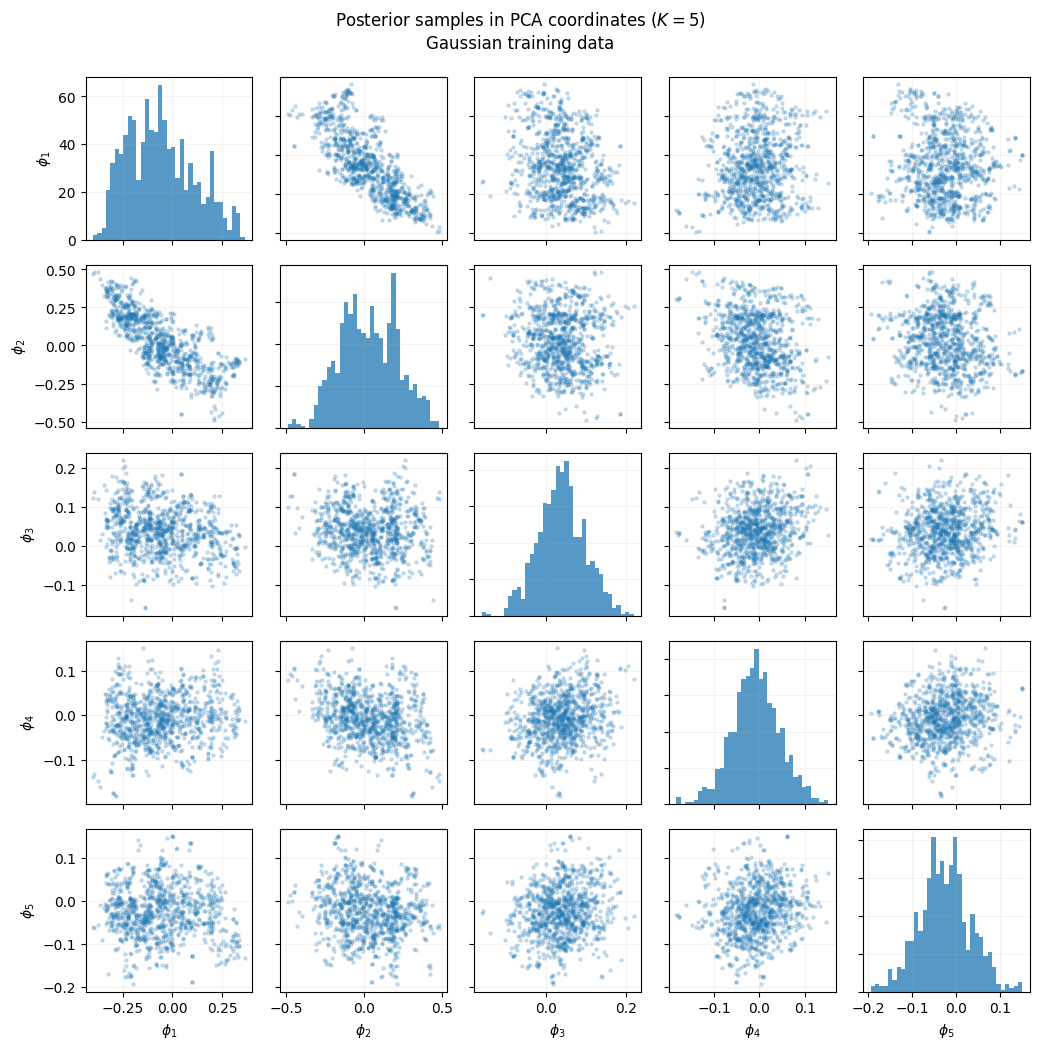

Saved: /content/simple_gaussian_example/figures/student_t_phi_pairplot.png


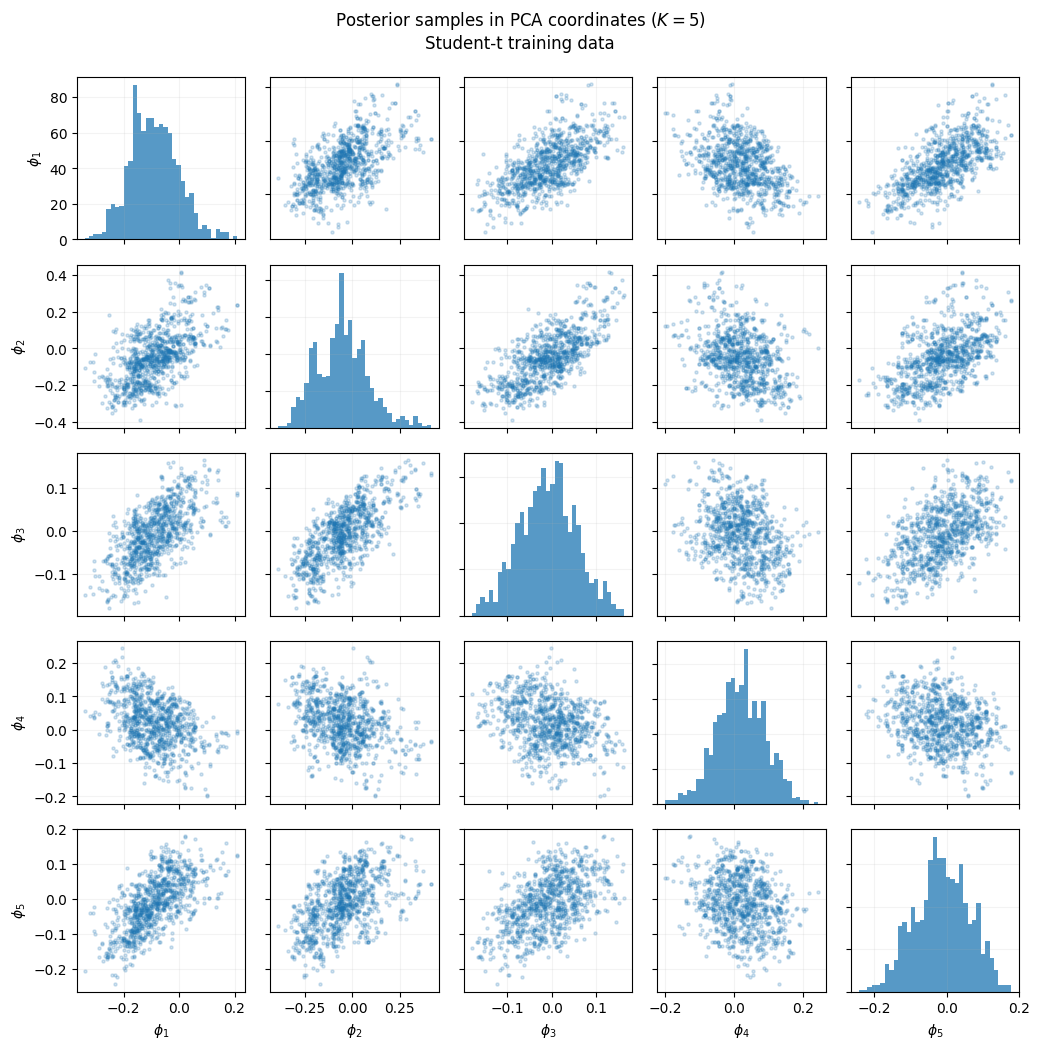

In [ ]:
for df in T_DFs:

    # -------------------------------------------------------------
    # Load posterior samples
    # -------------------------------------------------------------

    posterior_path = (
        CHECKPOINT_DIR
        / f"{get_df_label(df)}_posterior_samples.pt"
    )

    if not posterior_path.exists():
        raise FileNotFoundError(
            f"Missing posterior file: {posterior_path}"
        )

    posterior = torch.load(
        posterior_path,
        map_location="cpu",
        weights_only=False,
    )

    phi_samples = posterior[
        "phi_samples"
    ].numpy()

    K = phi_samples.shape[1]

    # -------------------------------------------------------------
    # Pair plot
    # -------------------------------------------------------------

    fig, axes = plt.subplots(
        K,
        K,
        figsize=(2.1 * K, 2.1 * K),
        squeeze=False,
    )

    for i in range(K):
        for j in range(K):

            ax = axes[i, j]

            if i == j:

                ax.hist(
                    phi_samples[:, i],
                    bins=35,
                    alpha=0.75,
                )

            else:

                ax.scatter(
                    phi_samples[:, j],
                    phi_samples[:, i],
                    s=5,
                    alpha=0.20,
                )

            if i == K - 1:
                ax.set_xlabel(
                    rf"$\phi_{j+1}$"
                )
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(
                    rf"$\phi_{i+1}$"
                )
            else:
                ax.set_yticklabels([])

            ax.grid(
                alpha=0.15
            )

    fig.suptitle(
        rf"Posterior samples in PCA coordinates ($K={K}$)"
        f"\n{get_df_label(df)}",
        y=0.995,
    )

    plt.tight_layout()

    # -------------------------------------------------------------
    # Save
    # -------------------------------------------------------------

    figure_path = (
        FIGURE_DIR
        / f"{get_df_label(df)}_phi_pairplot.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(
        f"Saved: {figure_path}"
    )

    plt.show()
    plt.close(fig)


## 5. Posterior predictive for the unseen source \(X^0\)

For every posterior sample,

\[
\phi^{(s)}\sim p(\phi\mid D),
\qquad
m_s=m_{\phi^{(s)}}(X^0).
\]

These \(m_s\) are samples from the posterior distribution of the target measure's mean.


In [ ]:
predictive_script = PROJECT_ROOT / "posterior_predictive.py"

if not predictive_script.exists():
    raise FileNotFoundError(
        f"Missing {predictive_script}"
    )

for df in T_DFs:
    pca_path = CHECKPOINT_DIR / f"{get_df_label(df)}_pca_subspace.pt"
    posterior_path = CHECKPOINT_DIR / f"{get_df_label(df)}_posterior_samples.pt"
    test_path = CHECKPOINT_DIR / f"gaussian_fixed_test_data.pt"
    predictive_path = CHECKPOINT_DIR / f"{get_df_label(df)}_posterior_predictive.pt"

    cmd = [
        sys.executable,
        "-u",
        str(predictive_script),
        "--pca", str(pca_path),
        "--posterior", str(posterior_path),
        "--test-data", str(test_path),
        "--output", str(predictive_path),
        "--num-predictive-models",
        str(min(500, ESS_NUM_SAMPLES)),
        "--seed",
        str(ESS_SEED + 1),
    ]

    process = subprocess.Popen(
        cmd,
        cwd=PROJECT_ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)

    return_code = process.wait()

    if return_code != 0:
        raise subprocess.CalledProcessError(
            return_code,
            cmd,
        )

Posterior predictive mean evaluation
Loading PCA checkpoint...
PCA checkpoint loaded.
Loading posterior samples...
Posterior samples loaded.
Loading test data...
Test data loaded.
Test source shape : (10, 128, 2)
Phi sample shape  : (1000, 5)
Device             : cuda
Constructing subspace model...
/content/simple_gaussian_example/models/gaussian_transformer.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
PCA dimension K = 5
Evaluating 500 posterior models on 10 test measures...
Posterior models: 50/500
Posterior models: 100/500
Posterior models: 150/500
Posterior models: 200/500
Posterior models: 250/500
Posterior models: 300/500
Posterior models: 350/500
Posterior models: 400/500
Posterior models: 450/500
Posterior models: 500/500
Saved posterior predictive means to: /content/simple_gaussian_example/checkpoints/gaussian_posterior_predictive.pt
Posterior predictive m

Saved: /content/simple_gaussian_example/figures/gaussian_vs_student_t_posterior_predictive.png


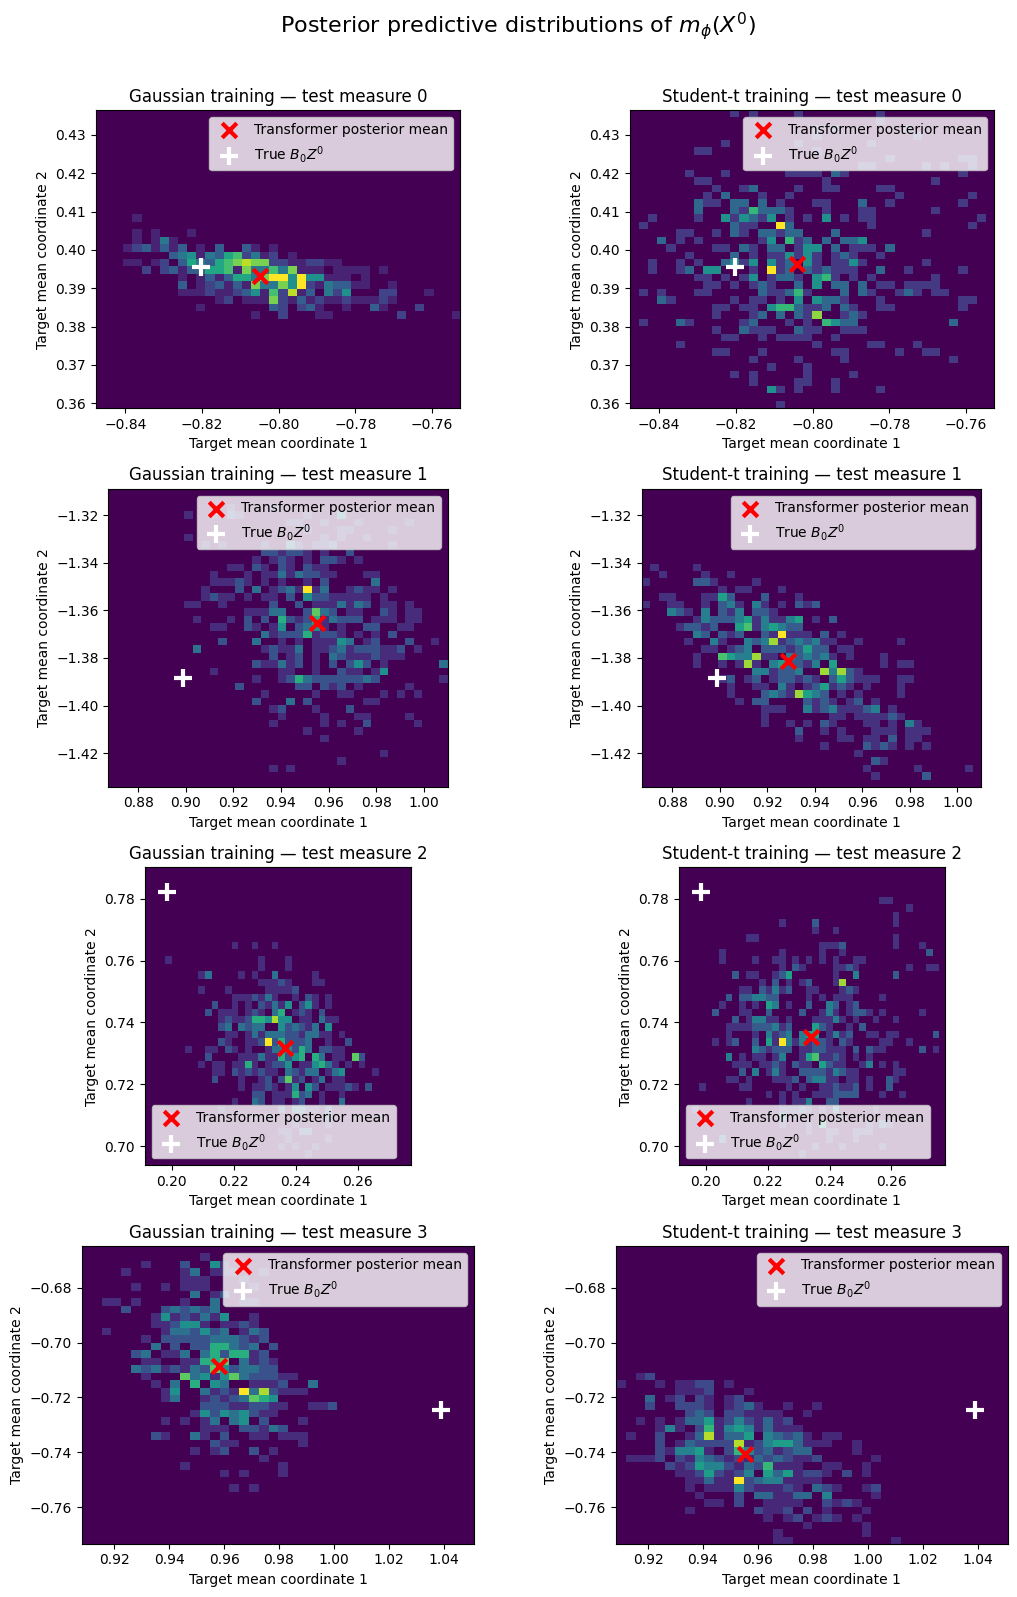

In [ ]:
n_plots = 4
predictive_results = {}

predictive_results = {}

for df in T_DFs:

    label = get_df_label(df)

    predictive_path = (
        CHECKPOINT_DIR
        / f"{label}_posterior_predictive.pt"
    )

    if not predictive_path.exists():
        raise FileNotFoundError(
            f"Missing {predictive_path}"
        )

    predictive_results[df] = torch.load(
        predictive_path,
        map_location="cpu",
        weights_only=False,
    )


# ---------------------------------------------------------------------
# Test data
#
# The same Gaussian test data should be used for every training df.
# ---------------------------------------------------------------------

test_data = predictive_results[T_DFs[0]]

source_test = test_data["source_test"]
latent_test = test_data["latent_test"]


# ---------------------------------------------------------------------
# Plot one figure for each test measure
# ---------------------------------------------------------------------

for measure_idx in range(n_plots):

    # ================================================================
    # Get true mean
    # ================================================================

    true_mean = (
        B0
        @ latent_test[measure_idx]
    ).numpy()


    # ================================================================
    # Collect all posterior samples first so that the same axis range
    # is used for every df for this test measure.
    # ================================================================

    all_samples = []

    for df in T_DFs:

        samples = (
            predictive_results[df][
                "posterior_means"
            ][:, measure_idx, :].numpy()
        )

        all_samples.append(
            samples
        )

    all_samples = np.concatenate(
        all_samples,
        axis=0,
    )

    x = all_samples[:, 0]
    y = all_samples[:, 1]


    # ================================================================
    # Common plotting range
    #
    # Use empirical quantiles to avoid one extreme outlier dominating
    # the plot, but explicitly include the true mean.
    # ================================================================

    x_low, x_high = np.quantile(
        x,
        [0.01, 0.99],
    )

    y_low, y_high = np.quantile(
        y,
        [0.01, 0.99],
    )

    x_low = min(
        x_low,
        true_mean[0],
    )

    x_high = max(
        x_high,
        true_mean[0],
    )

    y_low = min(
        y_low,
        true_mean[1],
    )

    y_high = max(
        y_high,
        true_mean[1],
    )

    x_range = x_high - x_low
    y_range = y_high - y_low

    x_pad = max(
        0.1 * x_range,
        1e-4,
    )

    y_pad = max(
        0.1 * y_range,
        1e-4,
    )

    x_min = x_low - x_pad
    x_max = x_high + x_pad

    y_min = y_low - y_pad
    y_max = y_high + y_pad


    plot_range = [
        [x_min, x_max],
        [y_min, y_max],
    ]


    # ================================================================
    # Figure
    # ================================================================

    fig, axes = plt.subplots(
        1,
        len(T_DFs),
        figsize=(4 * len(T_DFs), 4.5),
        squeeze=False,
    )

    axes = axes[0]


    # ================================================================
    # One column per df
    # ================================================================

    for ax, df in zip(
        axes,
        T_DFs,
    ):

        samples = (
            predictive_results[df][
                "posterior_means"
            ][:, measure_idx, :].numpy()
        )

        posterior_mean = samples.mean(
            axis=0
        )


        # ------------------------------------------------------------
        # Empirical 2D histogram
        # ------------------------------------------------------------

        counts, x_edges, y_edges = (
            np.histogram2d(
                samples[:, 0],
                samples[:, 1],
                bins=40,
                range=plot_range,
            )
        )

        probabilities = (
            counts / counts.sum()
        )


        ax.imshow(
            probabilities.T,
            origin="lower",
            extent=[
                x_edges[0],
                x_edges[-1],
                y_edges[0],
                y_edges[-1],
            ],
            aspect="equal",
            interpolation="nearest",
            cmap="viridis",
        )


        # ------------------------------------------------------------
        # Transformer posterior predictive mean
        # ------------------------------------------------------------

        ax.scatter(
            posterior_mean[0],
            posterior_mean[1],
            s=100,
            marker="x",
            linewidths=3,
            color="red",
            zorder=10,
        )


        # ------------------------------------------------------------
        # True population mean
        # ------------------------------------------------------------

        ax.scatter(
            true_mean[0],
            true_mean[1],
            s=160,
            marker="+",
            linewidths=3,
            color="white",
            zorder=11,
        )


        # ------------------------------------------------------------
        # Labels
        # ------------------------------------------------------------

        ax.set_title(
            get_df_label(df),
            fontsize=13,
        )

        ax.set_xlabel(
            "Target mean coordinate 1"
        )

        ax.set_ylabel(
            "Target mean coordinate 2"
        )

        ax.set_xlim(
            x_min,
            x_max,
        )

        ax.set_ylim(
            y_min,
            y_max,
        )

        ax.grid(
            alpha=0.15,
        )


    # ================================================================
    # Common legend
    # ================================================================

    axes[0].scatter(
        [],
        [],
        s=100,
        marker="x",
        linewidths=3,
        color="red",
        label="Transformer posterior mean",
    )

    axes[0].scatter(
        [],
        [],
        s=160,
        marker="+",
        linewidths=3,
        color="white",
        label=r"True $B_0Z^0$",
    )

    fig.legend(
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.5, 1.02),
    )


    # ================================================================
    # Figure title
    # ================================================================

    fig.suptitle(
        rf"Posterior predictive distribution of $m_\phi(X^0)$"
        f" — test measure {measure_idx}",
        fontsize=16,
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.91]
    )


    # ================================================================
    # Save
    # ================================================================

    figure_path = (
        FIGURE_DIR
        / f"posterior_predictive_df_sweep_measure_{measure_idx}.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(
        f"Saved: {figure_path}"
    )

    plt.show()
    plt.close(fig)

## Output files

The experiment leaves these reusable files in `checkpoints/`:

- `fixed_D_and_X0.pt` — frozen training dataset and unseen test pair;
- `pca_subspace_fixed_D.pt` — SWA point and PCA subspace;
- `posterior_phi.pt` — ESS samples of \(\phi\);
- `posterior_predictive_X0.pt` — posterior samples of the target mean and one predictive point-cloud realization.
